In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_sensitivity_results(result_dir):
    data = []

    for filename in os.listdir(result_dir):
        if filename.endswith(".txt"):
            match = re.match(r"features_(\d+)_(\d+)\.txt", filename)

            if match:
                feature = int(match.group(1))
                pruning_ratio = int(match.group(2))

                file_path = os.path.join(result_dir, filename)

                with open(file_path, "r") as f:
                    line = f.read()

                accuracy_match = re.search(r"\(([\d.]+)%\)", line)

                if accuracy_match:
                    accuracy = float(accuracy_match.group(1))

                    data.append({
                        "Feature": feature,
                        "Pruning Ratio": pruning_ratio,
                        "Accuracy": accuracy
                    })

    return data

In [3]:
def plot_sensitivity(df, title):
    plt.figure(figsize=(12, 7))

    for feature in sorted(df["Feature"].unique()):
        feature_data = df[df["Feature"] == feature]

        plt.plot(
            feature_data["Pruning Ratio"],
            feature_data["Accuracy"],
            marker="o",
            label=f"Feature {feature}"
        )

    plt.xlabel("Pruning Ratio (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title(title)

    plt.xticks(sorted(df["Pruning Ratio"].unique()))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [4]:
def get_top_pruning_ratios(df):
    top_results = []

    for feature in sorted(df["Feature"].unique()):
        feature_data = df[df["Feature"] == feature]
        top_three = feature_data.sort_values("Accuracy", ascending=False).head(3)

        for rank, (_, row) in enumerate(top_three.iterrows(), start=1):
            top_results.append({
                "Feature": int(row["Feature"]),
                "Rank": rank,
                "Pruning Ratio": int(row["Pruning Ratio"]),
                "Accuracy": row["Accuracy"]
            })

    return pd.DataFrame(top_results)

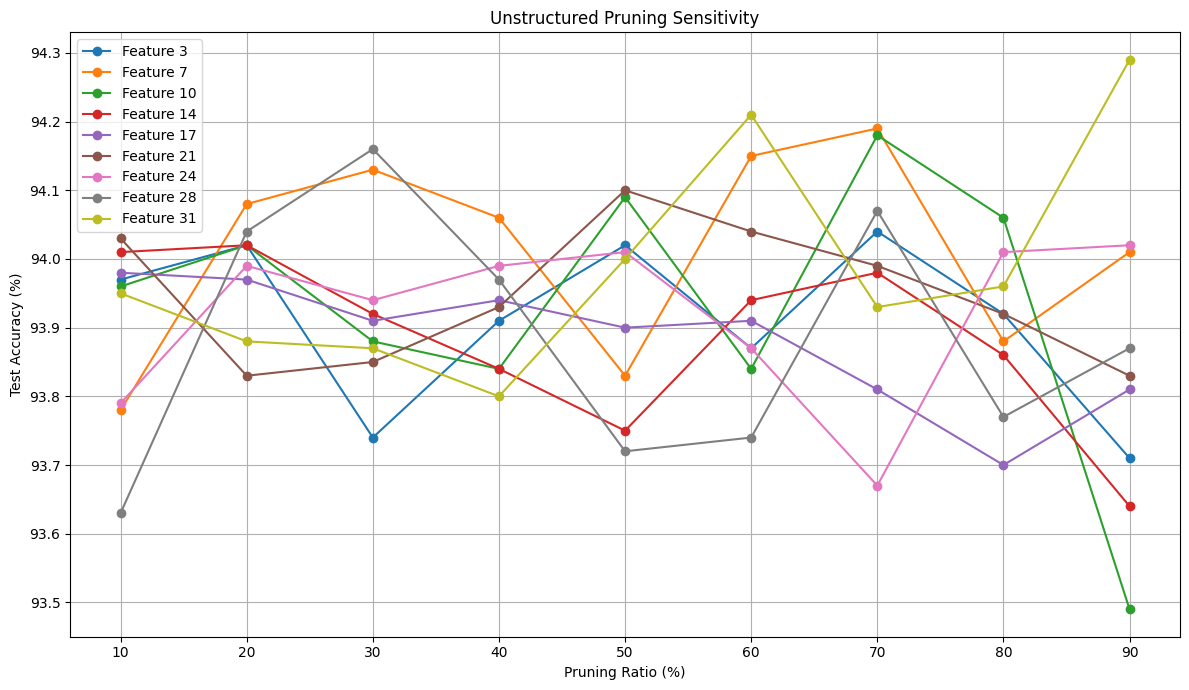

,Feature,Rank,Pruning Ratio,Accuracy
0,3,1,70,94.04
1,3,2,50,94.02
2,3,3,20,94.02
3,7,1,70,94.19
4,7,2,60,94.15
5,7,3,30,94.13
6,10,1,70,94.18
7,10,2,50,94.09
8,10,3,80,94.06
9,14,1,20,94.02


In [5]:
result_dir = "sensitivity_experiment/unstructured/result"

data = read_sensitivity_results(result_dir)

df = pd.DataFrame(data)
df = df.sort_values(["Feature", "Pruning Ratio"]).reset_index(drop=True)

plot_sensitivity(df, "Unstructured Pruning Sensitivity")

best_df = get_top_pruning_ratios(df)
best_df

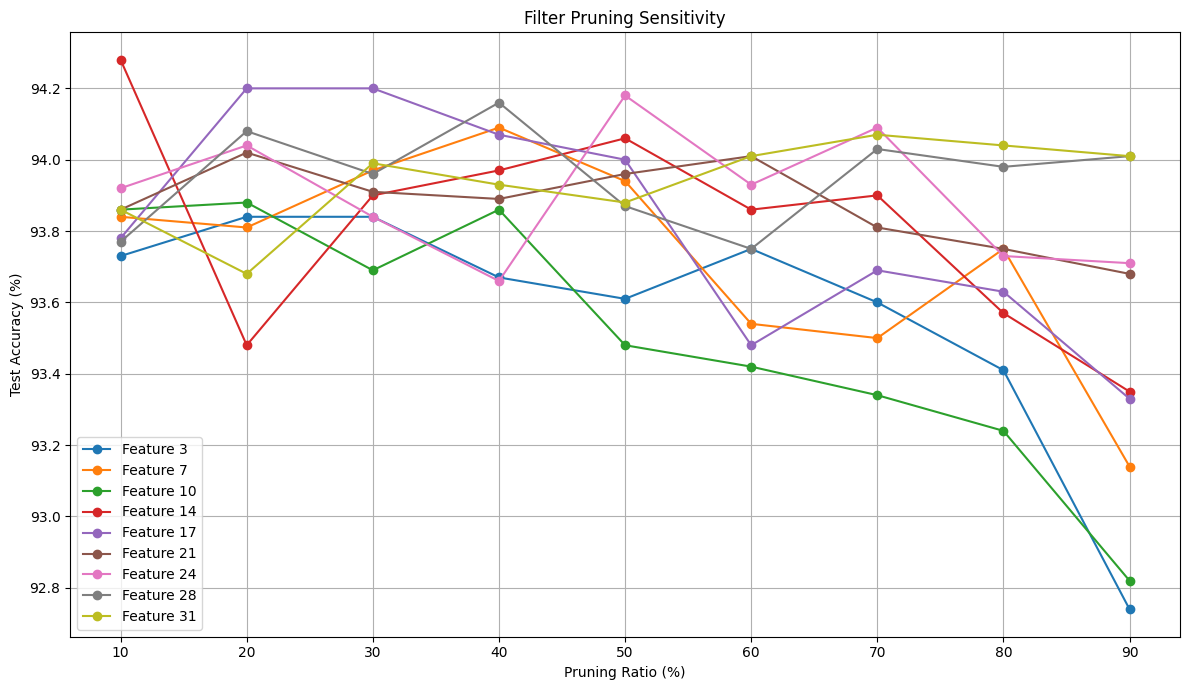

,Feature,Rank,Pruning Ratio,Accuracy
0,3,1,20,93.84
1,3,2,30,93.84
2,3,3,60,93.75
3,7,1,40,94.09
4,7,2,30,93.97
5,7,3,50,93.94
6,10,1,20,93.88
7,10,2,10,93.86
8,10,3,40,93.86
9,14,1,10,94.28


In [6]:
result_dir = "sensitivity_experiment/filter/result"

data = read_sensitivity_results(result_dir)

df = pd.DataFrame(data)
df = df.sort_values(["Feature", "Pruning Ratio"]).reset_index(drop=True)

plot_sensitivity(df, "Filter Pruning Sensitivity")

best_df = get_top_pruning_ratios(df)
best_df